In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

weather = ["Clear", "Rain", "Fog", "Snow"]
light = ["Daylight", "Night", "Dusk"]
road = ["Dry", "Wet", "Snow"]
speed_limits = [30, 40, 50, 60, 70]
vehicles = [1,2,3,4]

data = pd.DataFrame({
    "Weather_Conditions": np.random.choice(weather, n),
    "Light_Conditions": np.random.choice(light, n),
    "Road_Surface_Conditions": np.random.choice(road, n),
    "Speed_limit": np.random.choice(speed_limits, n),
    "Number_of_Vehicles": np.random.choice(vehicles, n)
})

severity = []

for i in range(n):

    score = 0

    if data.loc[i,"Weather_Conditions"] in ["Rain","Fog","Snow"]:
        score += 1

    if data.loc[i,"Light_Conditions"] == "Night":
        score += 1

    if data.loc[i,"Road_Surface_Conditions"] in ["Wet","Snow"]:
        score += 1

    if data.loc[i,"Speed_limit"] >= 60:
        score += 1

    if data.loc[i,"Number_of_Vehicles"] >= 3:
        score += 1

    if score <= 1:
        severity.append("Slight")
    elif score <=3:
        severity.append("Serious")
    else:
        severity.append("Fatal")

data["Accident_Severity"] = severity

data.head()

,Weather_Conditions,Light_Conditions,Road_Surface_Conditions,Speed_limit,Number_of_Vehicles,Accident_Severity
0,Fog,Night,Dry,50,3,Serious
1,Snow,Dusk,Dry,60,4,Serious
2,Clear,Daylight,Dry,50,2,Slight
3,Fog,Daylight,Wet,50,4,Serious
4,Fog,Daylight,Dry,40,1,Slight


In [2]:
data.to_csv("road_accident_dataset.csv", index=False)

In [3]:
import matplotlib.pyplot as plt

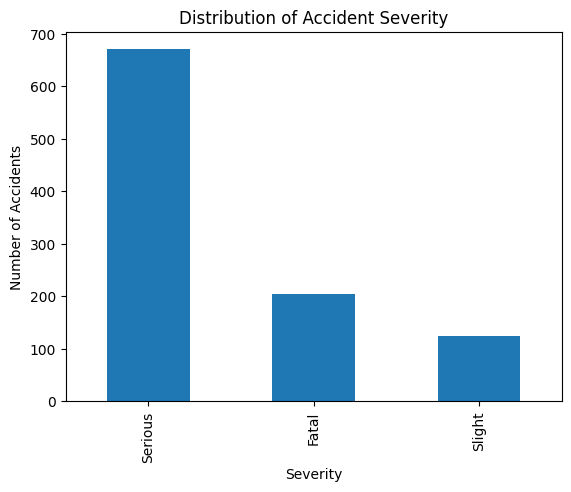

In [4]:
data["Accident_Severity"].value_counts().plot(kind="bar")

plt.title("Distribution of Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.show()

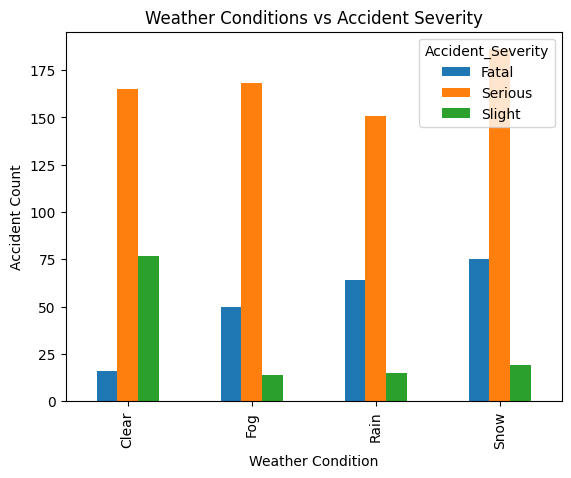

In [5]:
pd.crosstab(data["Weather_Conditions"], data["Accident_Severity"]).plot(kind="bar")

plt.title("Weather Conditions vs Accident Severity")
plt.xlabel("Weather Condition")
plt.ylabel("Accident Count")

plt.show()

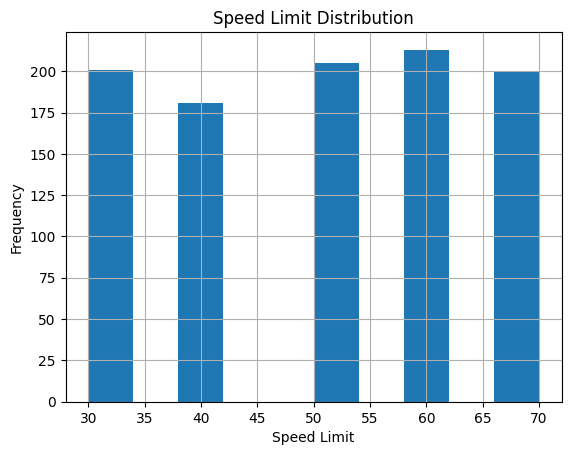

In [6]:
data["Speed_limit"].hist()

plt.title("Speed Limit Distribution")
plt.xlabel("Speed Limit")
plt.ylabel("Frequency")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [8]:
le = LabelEncoder()

data["Weather_Conditions"] = le.fit_transform(data["Weather_Conditions"])
data["Light_Conditions"] = le.fit_transform(data["Light_Conditions"])
data["Road_Surface_Conditions"] = le.fit_transform(data["Road_Surface_Conditions"])
data["Accident_Severity"] = le.fit_transform(data["Accident_Severity"])

In [9]:
X = data.drop("Accident_Severity", axis=1)
y = data["Accident_Severity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [10]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


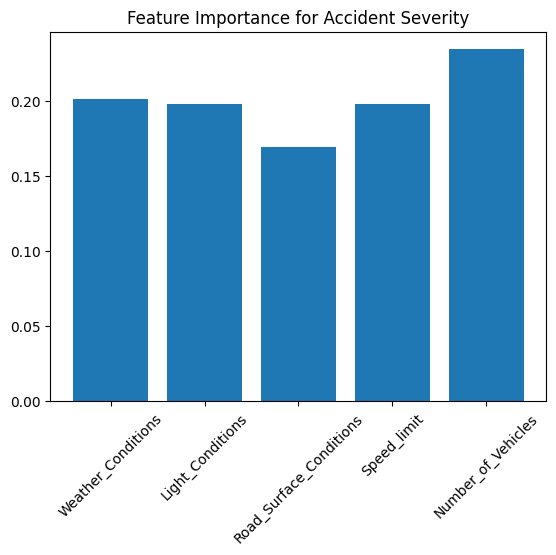

In [11]:
importance = model.feature_importances_

plt.bar(X.columns, importance)

plt.title("Feature Importance for Accident Severity")
plt.xticks(rotation=45)

plt.show()